# Feature Engineering

## Библиотеки и открытие файла

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from pathlib import Path

In [2]:
eda_bikes = pd.read_csv("datasets/eda.csv")

eda_bikes.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [3]:
eda_bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB


## Температура

На этапе EDA было выявлено, что atemp и temp коррелируют на 0.99. Иметь два этих поля одновременно крайне не оправдано, так как они получены из одного числа, и фактически могут быть выражены из друг друга

Для наилучшей интропритируемости, удалю atemp, так как "ощущения" субъективны, и числа для его вычисления можно сказать "взяты с потолка"

In [4]:
eda_bikes.drop("atemp", axis=1, inplace=True)

## Кодирование категориальных признаков

`weathersit` (1-4) и `season` (1-4) - категориальные переменные, закодированные целыми числами. Целочисленное представление некорректно: модели могут воспринять порядок как смысловой (например, лето=3 > весна=2), хотя такой смысл отсутствует.

Применяем **One-Hot Encoding** для обоих признаков. Все категории сохраняются (`drop_first=False`) - для деревьев мультиколлинеарность не является проблемой, а при использовании линейных моделей можно убрать одну колонку на этапе обучения.

In [5]:
weather_dummies = pd.get_dummies(eda_bikes["weathersit"], prefix="weather", dtype=int)
season_dummies = pd.get_dummies(eda_bikes["season"], prefix="season", dtype=int)

eda_bikes = pd.concat(
    [eda_bikes.drop(["weathersit", "season"], axis=1), weather_dummies, season_dummies],
    axis=1,
)

print("Добавлены колонки:", weather_dummies.columns.tolist() + season_dummies.columns.tolist())
eda_bikes.head()

Добавлены колонки: ['weather_1', 'weather_2', 'weather_3', 'weather_4', 'season_1', 'season_2', 'season_3', 'season_4']


,dteday,yr,mnth,hr,holiday,weekday,workingday,temp,hum,windspeed,cnt,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4
0,2011-01-01,0,1,0,0,6,0,0.24,0.81,0.0,16,1,0,0,0,1,0,0,0
1,2011-01-01,0,1,1,0,6,0,0.22,0.80,0.0,40,1,0,0,0,1,0,0,0
2,2011-01-01,0,1,2,0,6,0,0.22,0.80,0.0,32,1,0,0,0,1,0,0,0
3,2011-01-01,0,1,3,0,6,0,0.24,0.75,0.0,13,1,0,0,0,1,0,0,0
4,2011-01-01,0,1,4,0,6,0,0.24,0.75,0.0,1,1,0,0,0,1,0,0,0


## Дата и время

Для моделей цикличеность времени не очевидна, поэтому я закодирую месяцы и часы через sin и cos. Оригинальные значения я оставлю, так как дискретные шаги могут быть полезны для деревьев решений

### Часы

In [6]:
eda_bikes["hr_sin"] = np.sin(2 * np.pi * eda_bikes["hr"] / 24)
eda_bikes["hr_cos"] = np.cos(2 * np.pi * eda_bikes["hr"] / 24)

### Месяцы

In [7]:
eda_bikes["mnth_sin"] = np.sin(2 * np.pi * eda_bikes["mnth"] / 12)
eda_bikes["mnth_cos"] = np.cos(2 * np.pi * eda_bikes["mnth"] / 12)

### Года

В оригинальных данных есть флаг yr, который может быть или 0 (2011) или 1 (2012). Сам по себе он несет важную информацию, так как на этапе eda было выяснено, что спрос вырос на второй год. 

**С ним связано ограничение**: модель будет обучена на двух годах роста системы и не сможет быть экстраполированна за пределы обучающего периода. При inference с данными за 2026 поведение модели для деревьев предсказуемо (сплит yr > 0.5 будет стабильно срабатывать как yr=1), но систематически некорректно - модель не видела роста после 2012, а прогнозировать его в том же направлении не реалистично, особенно насколько за пределами обучаемых данных. Для других видов моделей подследствия могут быть еще менее предсказуемыми, поэтому далее в проекте все вводные данные не будут допускаться сильно за пределами обучаемого промежутка времени

### Удаление полей

Произведу удаление следующих полей:
- `dteday` - поле в формате datetime, не очень полезно для модели

In [8]:
eda_bikes.drop(["dteday"], axis=1, inplace=True)

In [9]:
eda_bikes.head()

,yr,mnth,hr,holiday,weekday,workingday,temp,hum,windspeed,cnt,...,weather_3,weather_4,season_1,season_2,season_3,season_4,hr_sin,hr_cos,mnth_sin,mnth_cos
0,0,1,0,0,6,0,0.24,0.81,0.0,16,...,0,0,1,0,0,0,0.000000,1.000000,0.5,0.866025
1,0,1,1,0,6,0,0.22,0.80,0.0,40,...,0,0,1,0,0,0,0.258819,0.965926,0.5,0.866025
2,0,1,2,0,6,0,0.22,0.80,0.0,32,...,0,0,1,0,0,0,0.500000,0.866025,0.5,0.866025
3,0,1,3,0,6,0,0.24,0.75,0.0,13,...,0,0,1,0,0,0,0.707107,0.707107,0.5,0.866025
4,0,1,4,0,6,0,0.24,0.75,0.0,1,...,0,0,1,0,0,0,0.866025,0.500000,0.5,0.866025


## Добавление новых полей на основе выводов EDA

Добавлю поля:
- `is_rush_time` - должно отражать активный период аренды для людей которые добираются на работу или с работы
- `discomfort` - индекс дискомфорта, будет вычисляться через перемножение температуры и влажности. Предположительно, если будет очень жарко и влажно люди будут меньше брать велосипеды на прокат
- `is_nigth` - должно отражать ночной период когда обычно люди спят


In [10]:
eda_bikes["is_rush_hour"] = (
    (eda_bikes["hr"].isin([7, 8, 9, 17, 18, 19])) & (eda_bikes["workingday"] == 1)
).astype(int)
eda_bikes["is_night"] = eda_bikes["hr"].between(0, 5).astype(int)
eda_bikes["discomfort"] = eda_bikes["temp"] * eda_bikes["hum"]

## Анализ влияния признаков на целевую переменную

Для оценки информативности признаков **без обучения модели** используются два подхода:

- **Корреляция Пирсона** `|r|` - измеряет линейную зависимость с `cnt`. Прост и быстр, но не улавливает нелинейность (например, `hr` имеет двугорбый паттерн, который линейная корреляция занизит)
- **Mutual Information** - измеряет любую зависимость (в том числе нелинейную) через информационную энтропию. Более точно отражает реальную предсказательную силу признака

Признаки с MI ≈ 0 или |r| < 0.05 практически не несут информации и являются кандидатами на удаление.

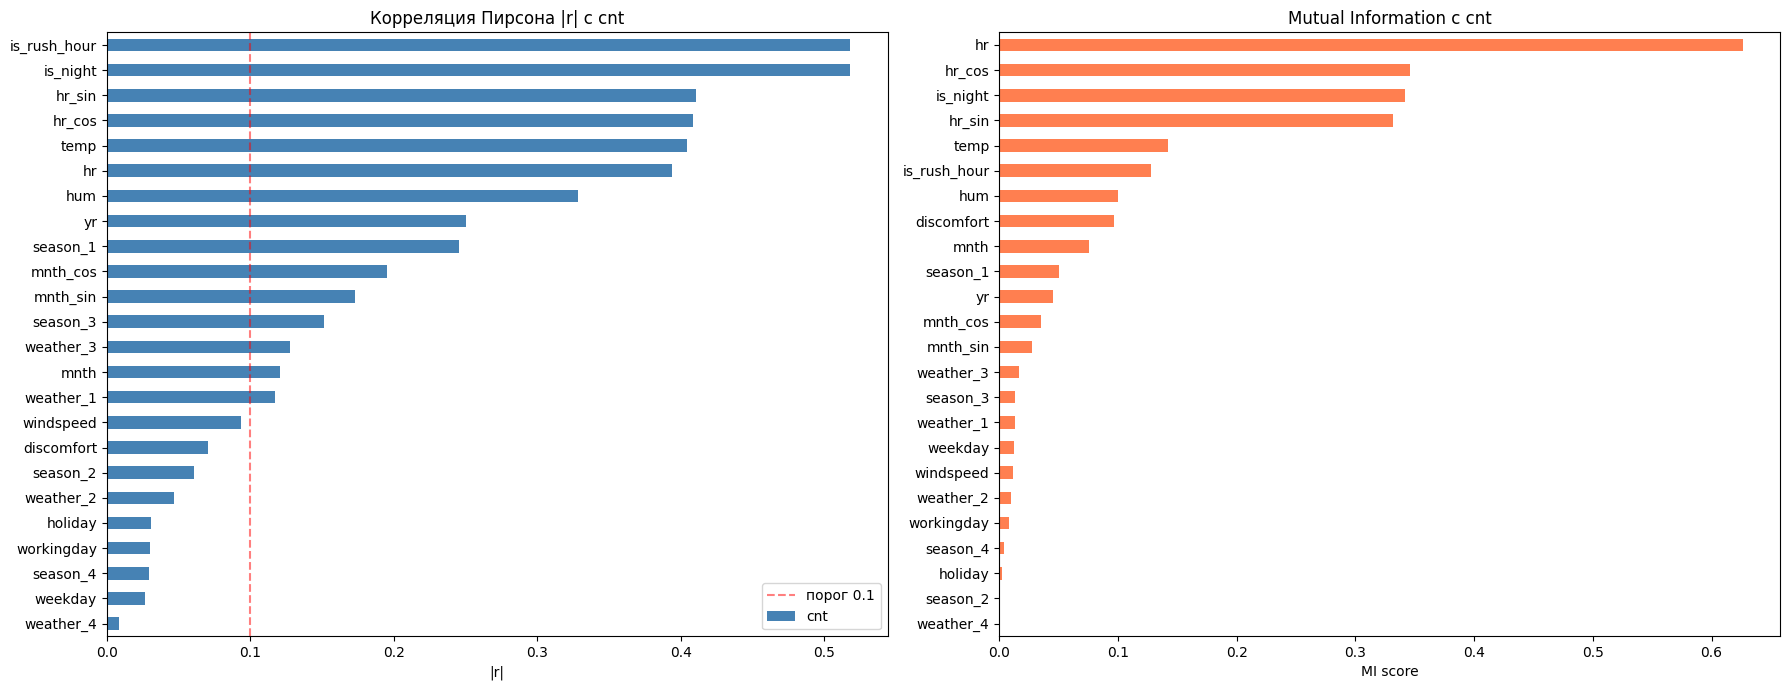

In [11]:
feature_cols = [c for c in eda_bikes.columns if c != "cnt"]

corr_target = (
    eda_bikes[feature_cols + ["cnt"]]
    .corr()["cnt"]
    .drop("cnt")
    .abs()
    .sort_values(ascending=True)
)

mi_scores = mutual_info_regression(
    eda_bikes[feature_cols].fillna(eda_bikes[feature_cols].median()),
    eda_bikes["cnt"],
    random_state=42,
)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr_target.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Корреляция Пирсона |r| с cnt")
axes[0].set_xlabel("|r|")
axes[0].axvline(0.1, color="red", linestyle="--", alpha=0.5, label="порог 0.1")
axes[0].legend()

mi_series.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Mutual Information с cnt")
axes[1].set_xlabel("MI score")

plt.tight_layout()
plt.show()

По результам, можно сказать, что созданные поля по пирсону являются очень ценными и важными

In [12]:
eda_bikes.head()

,yr,mnth,hr,holiday,weekday,workingday,temp,hum,windspeed,cnt,...,season_2,season_3,season_4,hr_sin,hr_cos,mnth_sin,mnth_cos,is_rush_hour,is_night,discomfort
0,0,1,0,0,6,0,0.24,0.81,0.0,16,...,0,0,0,0.000000,1.000000,0.5,0.866025,0,1,0.1944
1,0,1,1,0,6,0,0.22,0.80,0.0,40,...,0,0,0,0.258819,0.965926,0.5,0.866025,0,1,0.1760
2,0,1,2,0,6,0,0.22,0.80,0.0,32,...,0,0,0,0.500000,0.866025,0.5,0.866025,0,1,0.1760
3,0,1,3,0,6,0,0.24,0.75,0.0,13,...,0,0,0,0.707107,0.707107,0.5,0.866025,0,1,0.1800
4,0,1,4,0,6,0,0.24,0.75,0.0,1,...,0,0,0,0.866025,0.500000,0.5,0.866025,0,1,0.1800


## Преобразование целевой переменной (log1p)

`cnt` — счётчик аренды велосипедов. Счётные данные, как правило, имеют **правостороннюю асимметрию (right-skew)**: большинство часов — малый спрос, редкие пики — очень высокий.

### Проблема правостороннего скоса

Большинство регрессионных моделей минимизируют квадратичную функцию потерь:

$$\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

При правостороннем скосе большие выбросы квадратично доминируют в потере — модель "тянется" подстраиваться под пики, теряя точность на типичных значениях.

### Логарифмическое преобразование

Чтобы избежать $\log(0) = -\infty$ при нулевых значениях, применяем `log1p`:

$$y' = \log(1 + y)$$

Обратное преобразование (при inference):

$$\hat{y} = e^{y'} - 1 = \operatorname{expm1}(y')$$

### Связь с нормальным распределением

Если случайная величина $y$ имеет **логнормальное** распределение $y \sim \mathrm{LogNormal}(\mu,\, \sigma^2)$, то по определению:

$$\log(y) \sim \mathcal{N}(\mu,\, \sigma^2)$$

Спрос на прокат велосипедов близок к логнормальному (мультипликативные факторы погоды, времени суток), поэтому $\log(1 + y)$ приближает распределение к нормальному.

Более строго — **теорема о стабилизации дисперсии**: для данных, где $\mathrm{Var}(y) \propto \mathbb{E}[y]^2$ (логнормальное или отрицательное биномиальное распределение), преобразование $\log(y)$ стабилизирует дисперсию, делая её приблизительно постоянной по всему диапазону $y$:

$$\mathrm{Var}(\log y) \approx \frac{\mathrm{Var}(y)}{\mathbb{E}[y]^2} = \sigma^2 \approx \mathrm{const}$$

### RMSLE как метрика в log-пространстве

Обучение модели в log-пространстве эквивалентно минимизации **RMSLE**:

$$\mathrm{RMSLE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\bigl(\log(1+y_i) - \log(1+\hat{y}_i)\bigr)^2}$$

Эта метрика штрафует **относительные ошибки**, а не абсолютные, что справедливо для счётных данных со скосом: ошибка на 50 велосипедов при спросе 100 воспринимается так же, как ошибка на 5 при спросе 10.

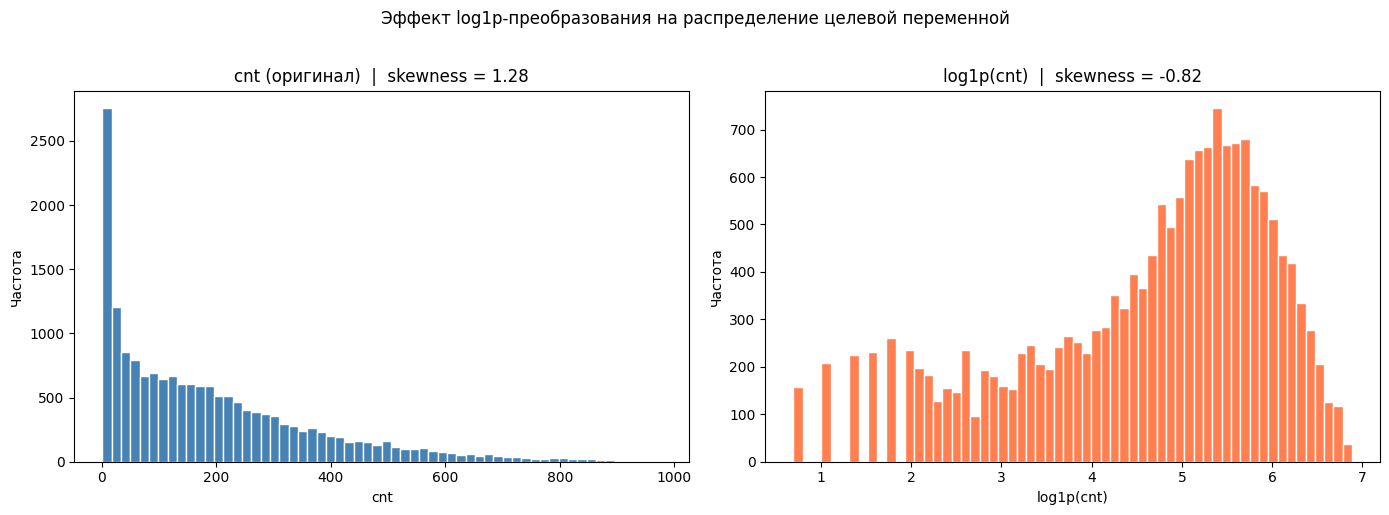

Преобразование применено: cnt = log1p(cnt)
  min: 0.693
  max: 6.886
  skewness: -0.818


In [13]:

cnt_log = np.log1p(eda_bikes["cnt"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(eda_bikes["cnt"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title(f"cnt (оригинал)  |  skewness = {eda_bikes['cnt'].skew():.2f}")
axes[0].set_xlabel("cnt")
axes[0].set_ylabel("Частота")

axes[1].hist(cnt_log, bins=60, color="coral", edgecolor="white")
axes[1].set_title(f"log1p(cnt)  |  skewness = {cnt_log.skew():.2f}")
axes[1].set_xlabel("log1p(cnt)")
axes[1].set_ylabel("Частота")

plt.suptitle("Эффект log1p-преобразования на распределение целевой переменной", y=1.02)
plt.tight_layout()
plt.show()

eda_bikes["cnt"] = cnt_log
print("Преобразование применено: cnt = log1p(cnt)")
print(f"  min: {eda_bikes['cnt'].min():.3f}")
print(f"  max: {eda_bikes['cnt'].max():.3f}")
print(f"  skewness: {eda_bikes['cnt'].skew():.3f}")

## Выводы по Feature Engineering

### Итоговый набор признаков

| Группа | Признаки |
|--------|----------|
| Временные (дискретные) | `yr`, `mnth`, `hr`, `weekday`, `holiday`, `workingday` |
| Временные (циклические) | `hr_sin`, `hr_cos`, `mnth_sin`, `mnth_cos` |
| Погодные | `temp`, `hum`, `windspeed` |
| Категориальные (OHE) | `weather_1..4`, `season_1..4` |
| Engineered | `is_rush_hour`, `is_night`, `discomfort` |
| **Целевая переменная** | `cnt` (log1p-преобразована) |

### Ключевые решения
- **`atemp` удалён** - корреляция с `temp` равна 0.99, признак избыточен
- **`dteday` удалён** - дата закодирована через `yr`, `mnth`, циклические признаки
- **OHE** для `weathersit` и `season` - исключает ложный порядок в категориях
- **Циклическое кодирование** `hr` и `mnth` - позволяет линейным моделям улавливать цикличность
- **`is_rush_hour`** - захватывает двойной пик спроса в рабочие дни (7–9 и 17–19 ч.)
- **`discomfort` = temp x hum** - взаимодействие жары и влажности
- **`cnt` = log1p(cnt)** - логарифмическое преобразование стабилизирует дисперсию и приближает распределение к нормальному; при inference используется `expm1`

## Разбиение и сохранение

Данные разделяются **хронологически** - случайный split недопустим для временных рядов, так как создаёт утечку данных из будущего в обучение.

| Сплит | Период | Обоснование |
|-------|--------|-------------|
| **Train** | 2011 (yr=0) | Обучение модели |
| **Validation** | 2012 январь–июнь (yr=1, mnth≤6) | Подбор гиперпараметров |
| **Test** | 2012 июль–декабрь (yr=1, mnth>7) | Финальная оценка качества |

In [14]:

train = eda_bikes[eda_bikes["yr"] == 0].copy()
val = eda_bikes[(eda_bikes["yr"] == 1) & (eda_bikes["mnth"] <= 6)].copy()
test = eda_bikes[(eda_bikes["yr"] == 1) & (eda_bikes["mnth"] > 6)].copy()

print(f"Train:      {len(train):>6} строк  ({len(train) / len(eda_bikes) * 100:.1f}%)")
print(f"Validation: {len(val):>6} строк  ({len(val) / len(eda_bikes) * 100:.1f}%)")
print(f"Test:       {len(test):>6} строк  ({len(test) / len(eda_bikes) * 100:.1f}%)")
print(
    f"\nКолонок в датасете: {eda_bikes.shape[1]}  (признаков: {
        eda_bikes.shape[1] - 1
    }, целевая: cnt)"
)

Path("datasets/clean").mkdir( exist_ok=True)
train.to_csv("datasets/clean/train.csv", index=False)
val.to_csv("datasets/clean/validation.csv", index=False)
test.to_csv("datasets/clean/test.csv", index=False)

print("\nСохранено:")
print("  datasets/clean/train.csv")
print("  datasets/clean/validation.csv")
print("  datasets/clean/test.csv")

Train:        8645 строк  (49.7%)
Validation:   4358 строк  (25.1%)
Test:         4376 строк  (25.2%)

Колонок в датасете: 25  (признаков: 24, целевая: cnt)

Сохранено:
  datasets/clean/train.csv
  datasets/clean/validation.csv
  datasets/clean/test.csv
